# RouteFinder on Solomon VRPTW

Train a `RouteFinderPolicy` for 3 epochs on 50-customer synthetic VRPTW data, then evaluate it on Solomon RC instances from the dataset folder and compare against OR-Tools.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
from tensordict import TensorDict
import pandas as pd
import torch
from IPython.display import display
from rl4co.utils.trainer import RL4COTrainer

sys.path.append(str(Path('..').resolve() / 'src'))

from dvrptw_bench.data.instance_filters import find_rc_instances
from dvrptw_bench.data.solomon_parser import parse_solomon
from dvrptw_bench.heuristics.ortools_solver import ORToolsVRPTWSolver
from dvrptw_bench.metrics.objective import total_distance
from dvrptw_bench.rl.routefinder_adapter import instance_to_routefinder_td, routefinder_actions_to_solution
from dvrptw_bench.rl.mtvrp_solomon_generator import SolomonMTVRPGenerator
from dvrptw_bench.rl.mtvrp_solomon_generator import MTVRPGenerator
from dvrptw_bench.viz.route_plot import plot_routes
from dvrptw_bench.common.typing import VRPTWInstance
from routefinder.envs.mtvrp import MTVRPEnv, MTVRPGenerator
from routefinder.models import RouteFinderBase, RouteFinderPolicy
from routefinder.utils import evaluate as evaluate_routefinder

In [2]:
DATASET_ROOT = Path('../dataset/solomon_rc100')
RC_DATASET_ROOT = Path('../dataset/solomon_rc100')
C_DATASET_ROOT = Path('../dataset/solomon_c100')
OUTPUT_ROOT = Path('../outputs/notebook_routefinder')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

NUM_CUSTOMERS = 50
NUM_EPOCHS = 200
BATCH_SIZE = 256
TRAIN_DATA_SIZE = 100_000
VAL_DATA_SIZE = 10_000
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-6
NUM_AUGMENT = 8
ORTOOLS_TIME_LIMIT_S = 3
MAX_EVAL_INSTANCES = 5  # set to None to evaluate all RC instances
NORMALIZE_COORDS = True # whether to normalize coordinates to [0, 1] when creating RouteFinder training data

if torch.cuda.is_available():
    device = torch.device('cuda')
    accelerator = 'gpu'
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    device = torch.device('mps')
    accelerator = 'mps'
else:
    device = torch.device('cpu')
    accelerator = 'cpu'

print('Device:', device)
print('Dataset root:', DATASET_ROOT.resolve())
print('Output root:', OUTPUT_ROOT.resolve())


Device: mps
Dataset root: /Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/dataset/solomon_rc100
Output root: /Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/outputs/notebook_routefinder


In [3]:
from dvrptw_bench.rl.routefinder_adapter import _normalize_coord

def normalize_coord(coord:torch.Tensor) -> torch.Tensor:
    x, y = coord[:, 0], coord[:, 1]
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    
    x_scaled = (x - x_min) / (x_max - x_min) 
    y_scaled = (y - y_min) / (y_max - y_min)
    coord_scaled = torch.stack([x_scaled, y_scaled], dim=1)
    return coord_scaled 

def instance_to_generator_td(instance, num_customers):
    coords = [(instance.depot.x, instance.depot.y)] + [
        (c.x, c.y) for c in instance.customers
    ]

    locs = torch.tensor(coords, dtype=torch.float32)

    # enforce size
    assert locs.shape[0] >= num_customers + 1
    locs = locs[: num_customers + 1]

    # normalize
    if NORMALIZE_COORDS:
        # locs = locs / 100.0
        locs = normalize_coord(locs)

    return locs
def build_solomon_training_item(instance, num_customers, normalize_coords=True, target_max_time=4.6):
    customers = instance.customers[:num_customers]

    coords = [(instance.depot.x, instance.depot.y)] + [(c.x, c.y) for c in customers]
    locs = torch.tensor(coords, dtype=torch.float32)

    if normalize_coords:
        locs = normalize_coord(locs)

    ready = torch.tensor(
        [instance.depot.ready_time] + [c.ready_time for c in customers],
        dtype=torch.float32,
    )
    due = torch.tensor(
        [instance.depot.due_time] + [c.due_time for c in customers],
        dtype=torch.float32,
    )
    service = torch.tensor(
        [0.0] + [c.service_time for c in customers],
        dtype=torch.float32,
    )
    demand = torch.tensor(
        [c.demand for c in customers],
        dtype=torch.float32,
    )

    time_windows = torch.stack([ready, due], dim=-1)

    depot_due = time_windows[0, 1].item()
    alpha = target_max_time / max(depot_due, 1e-8)

    time_windows = time_windows * alpha
    service = service * alpha

    time_windows[0, 0] = 0.0
    time_windows[0, 1] = target_max_time
    service[0] = 0.0

    return {
        "locs": locs,                          # [N+1, 2]
        "time_windows": time_windows,          # [N+1, 2]
        "service_time": service,               # [N+1]
        "demand_linehaul": demand,             # [N]
        "vehicle_capacity": float(instance.vehicle_capacity),
        "instance_id": instance.instance_id,
        "alpha": alpha,
    }

rcInstances = [parse_solomon(instance, max_customers=NUM_CUSTOMERS) for instance in find_rc_instances(RC_DATASET_ROOT)]
cInstances = [parse_solomon(instance, max_customers=NUM_CUSTOMERS) for instance in find_rc_instances(C_DATASET_ROOT)]
# generatorSolomonInstances = [instance_to_generator_td(instance, NUM_CUSTOMERS) for instance in rcInstances] + [instance_to_generator_td(instance, NUM_CUSTOMERS) for instance in cInstances]
generatorSolomonInstances = (
    [
        build_solomon_training_item(
            instance,
            num_customers=NUM_CUSTOMERS,
            normalize_coords=NORMALIZE_COORDS,
            target_max_time=4.6,
        )
        for instance in rcInstances
    ]
    +
    [
        build_solomon_training_item(
            instance,
            num_customers=NUM_CUSTOMERS,
            normalize_coords=NORMALIZE_COORDS,
            target_max_time=4.6,
        )
        for instance in cInstances
    ]
)

In [7]:
print(type(generatorSolomonInstances[0]))
print(generatorSolomonInstances[0].keys())
generator(2)
td = generator(2)
print(td["locs"].shape)
print(td["time_windows"].shape)
print(td["service_time"].shape)
print(td["demand_linehaul"].shape)

<class 'dict'>
dict_keys(['locs', 'time_windows', 'service_time', 'demand_linehaul', 'vehicle_capacity', 'instance_id', 'alpha'])
torch.Size([2, 51, 2])
torch.Size([2, 51, 2])
torch.Size([2, 51])
torch.Size([2, 50])


In [8]:

generator = SolomonMTVRPGenerator(num_loc=NUM_CUSTOMERS, variant_preset='vrptw', solomon_instances=generatorSolomonInstances)
env = MTVRPEnv(generator, check_solution=False)
policy = RouteFinderPolicy(env_name=env.name).to(device)
model = RouteFinderBase(
    env,
    policy,
    batch_size=BATCH_SIZE,
    train_data_size=TRAIN_DATA_SIZE,
    val_data_size=VAL_DATA_SIZE,
    optimizer_kwargs={'lr': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY},
)

trainer = RL4COTrainer(
    max_epochs=NUM_EPOCHS,
    accelerator=accelerator,
    devices=1,
    logger=None,
    precision='32-true',
)

trainer.fit(model) 
# trainer.save_checkpoint(OUTPUT_ROOT / 'end_of_training.pt')
# model = model.load_from_checkpoint(OUTPUT_ROOT / 'checkpoints/epoch-199.ckpt', weights_only=False, map_location=torch.device('cpu'))

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try install

┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ env      │ MTVRPEnv          │      0 │ train │     0 │
│ 1 │ policy   │ RouteFinderPolicy │  1.3 M │ train │     0 │
│ 2 │ baseline │ SharedBaseline    │      0 │ train │     0 │
└───┴──────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 1.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.3 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 112                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/ut
ilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/tr
ainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve 
performance.

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/tr
ainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a 
bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to 
improve performance.


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
instance_paths = find_rc_instances(DATASET_ROOT)
assert instance_paths, f'No RC instances found under {DATASET_ROOT.resolve()}'

if MAX_EVAL_INSTANCES is not None:
    instance_paths = instance_paths[:MAX_EVAL_INSTANCES]

instances = [parse_solomon(path, max_customers=NUM_CUSTOMERS) for path in instance_paths]
print('Loaded instances:', [instance.instance_id for instance in instances])


def solve_with_routefinder(instance, num_augment=NUM_AUGMENT):
    t0 = time.perf_counter()
    td = instance_to_routefinder_td(instance, normalize_coords=NORMALIZE_COORDS).to(device)
    td_reset = env.reset(td)
    model.to(device).eval()

    with torch.inference_mode():
        if num_augment > 1:
            out = evaluate_routefinder(model, td_reset.clone(), num_augment=num_augment)
            actions = out.get('best_aug_actions', out.get('best_multistart_actions', out.get('actions')))
        else:
            out = model.policy(
                td_reset.clone(),
                env,
                phase='test',
                decode_type='sampling',
                return_actions=True,
            )
            actions = out['actions']

    solution = routefinder_actions_to_solution(actions, instance, strategy='routefinder')
    solution.total_distance = total_distance(instance, solution)
    solution.solve_time_s = time.perf_counter() - t0
    solution.details.update({'num_augment': num_augment})
    return solution

ortools = ORToolsVRPTWSolver()
routefinder_solutions = {}
ortools_solutions = {}
rows = []

for instance in instances:
    rf_solution = solve_with_routefinder(instance)
    or_solution = ortools.solve(instance, time_limit_s=ORTOOLS_TIME_LIMIT_S)

    routefinder_solutions[instance.instance_id] = rf_solution
    ortools_solutions[instance.instance_id] = or_solution

    gap_pct = 100.0 * (rf_solution.total_distance - or_solution.total_distance) / or_solution.total_distance
    rows.append(
        {
            'instance_id': instance.instance_id,
            'n_customers': instance.n_customers,
            'routefinder_distance': rf_solution.total_distance,
            'ortools_distance': or_solution.total_distance,
            'gap_to_ortools_pct': gap_pct,
            'routefinder_routes': len([r for r in rf_solution.routes if r.node_ids]),
            'ortools_routes': len([r for r in or_solution.routes if r.node_ids]),
            'routefinder_time_s': rf_solution.solve_time_s,
            'ortools_time_s': or_solution.solve_time_s,
        }
    )

results_df = pd.DataFrame(rows).sort_values('gap_to_ortools_pct').reset_index(drop=True)
results_df[['routefinder_distance', 'ortools_distance', 'gap_to_ortools_pct', 'routefinder_time_s', 'ortools_time_s']] = results_df[[
    'routefinder_distance', 'ortools_distance', 'gap_to_ortools_pct', 'routefinder_time_s', 'ortools_time_s'
]].round(3)

display(results_df)
results_df.to_csv(OUTPUT_ROOT / 'routefinder_vs_ortools.csv', index=False)
print('Saved table to', OUTPUT_ROOT / 'routefinder_vs_ortools.csv')


Loaded instances: ['RC201.txt', 'RC202.txt', 'RC203.txt', 'RC204.txt', 'RC205.txt']
Scaling times to target max time 4.6 with depot due time 11.321844100952148 and epsilon 1e-08
Scaling times to target max time 4.6 with depot due time 11.321844100952148 and epsilon 1e-08
Scaling times to target max time 4.6 with depot due time 11.321844100952148 and epsilon 1e-08
Scaling times to target max time 4.6 with depot due time 11.321844100952148 and epsilon 1e-08
Scaling times to target max time 4.6 with depot due time 11.321844100952148 and epsilon 1e-08


,instance_id,n_customers,routefinder_distance,ortools_distance,gap_to_ortools_pct,routefinder_routes,ortools_routes,routefinder_time_s,ortools_time_s
0,RC205.txt,50,780.0,619.0,26.010,6,5,0.292,3.001
1,RC201.txt,50,871.0,675.0,29.037,7,5,0.963,3.225
2,RC202.txt,50,830.0,605.0,37.190,5,5,0.246,3.001
3,RC203.txt,50,773.0,546.0,41.575,5,4,0.455,3.000
4,RC204.txt,50,759.0,436.0,74.083,6,3,0.296,3.001


Saved table to ../outputs/notebook_routefinder/routefinder_vs_ortools.csv


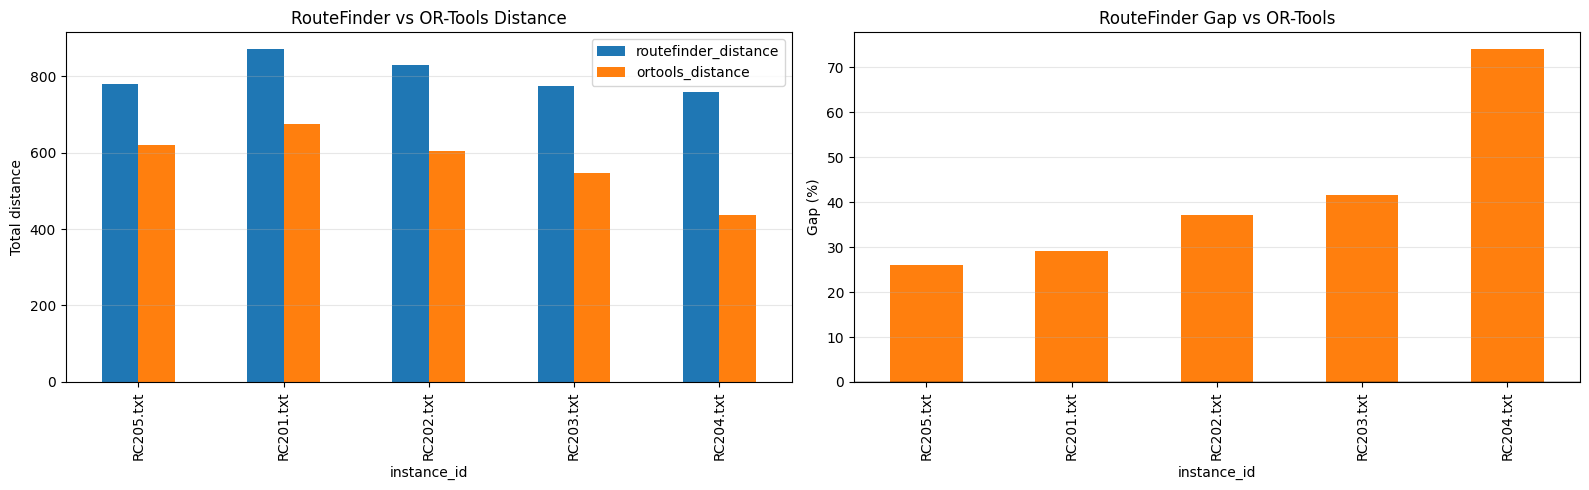

Saved summary plot to ../outputs/notebook_routefinder/routefinder_vs_ortools_summary.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_df = results_df.set_index('instance_id')
plot_df[['routefinder_distance', 'ortools_distance']].plot(kind='bar', ax=axes[0])
axes[0].set_title('RouteFinder vs OR-Tools Distance')
axes[0].set_ylabel('Total distance')
axes[0].grid(axis='y', alpha=0.3)

plot_df['gap_to_ortools_pct'].plot(kind='bar', ax=axes[1], color='tab:orange')
axes[1].axhline(0.0, color='black', linewidth=1)
axes[1].set_title('RouteFinder Gap vs OR-Tools')
axes[1].set_ylabel('Gap (%)')
axes[1].grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(OUTPUT_ROOT / 'routefinder_vs_ortools_summary.png', dpi=180)
plt.show()
print('Saved summary plot to', OUTPUT_ROOT / 'routefinder_vs_ortools_summary.png')



=== RC201.txt ===
RouteFinder distance: 871.0
OR-Tools distance: 675.0

=== RC202.txt ===
RouteFinder distance: 830.0
OR-Tools distance: 605.0

=== RC203.txt ===
RouteFinder distance: 773.0
OR-Tools distance: 546.0


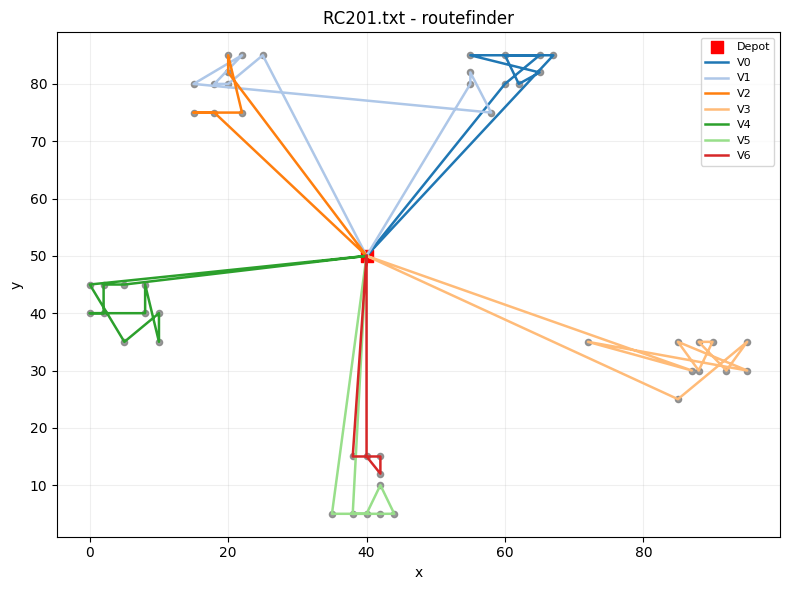

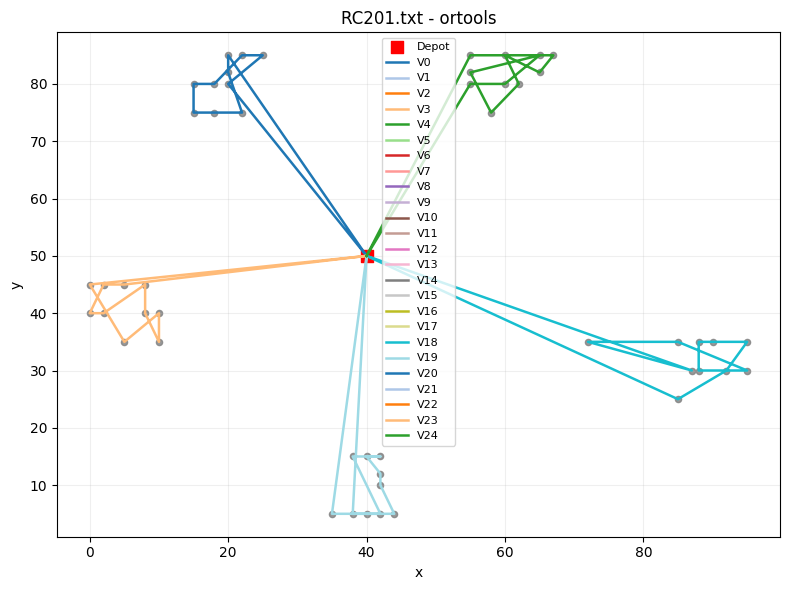

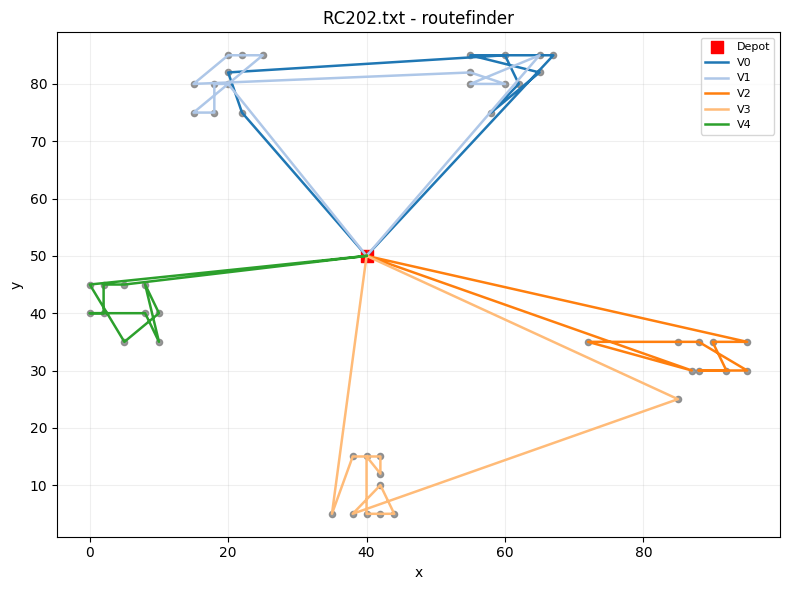

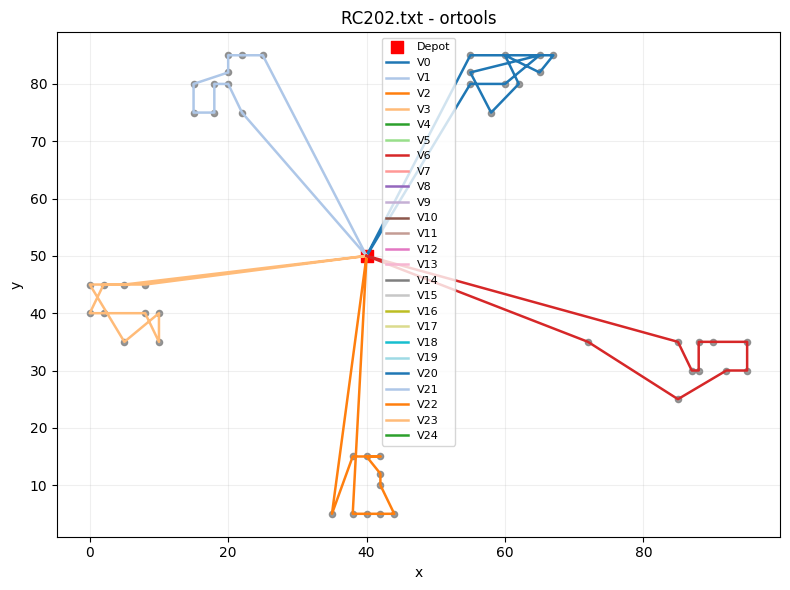

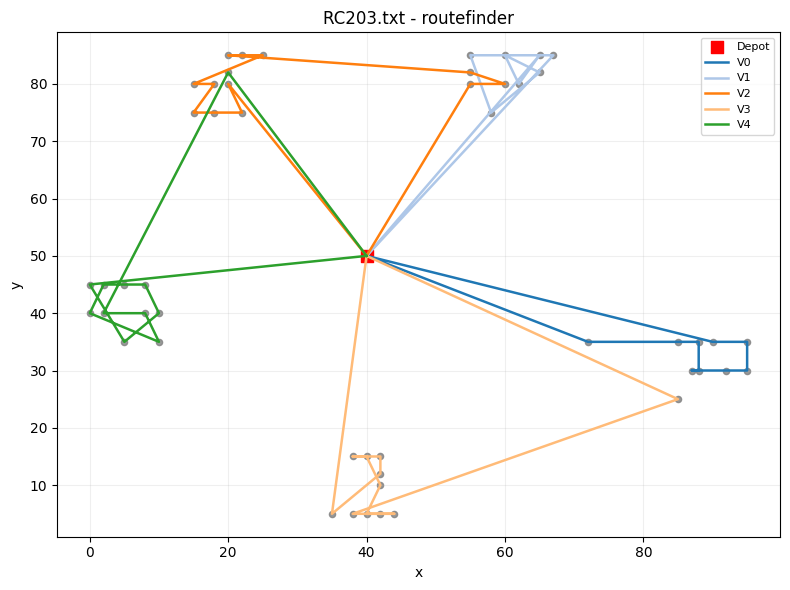

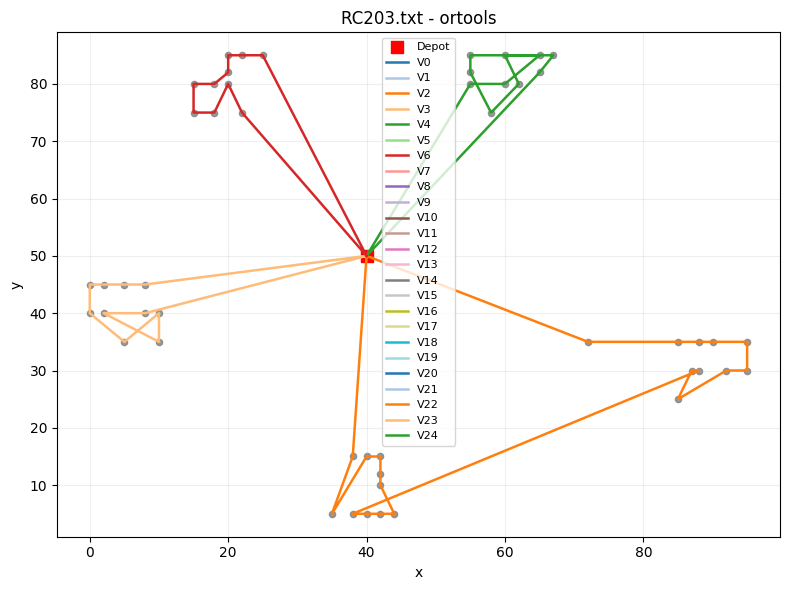

In [ ]:
for instance in instances[: min(3, len(instances))]:
    print(f'\n=== {instance.instance_id} ===')
    print('RouteFinder distance:', routefinder_solutions[instance.instance_id].total_distance)
    print('OR-Tools distance:', ortools_solutions[instance.instance_id].total_distance)
    plot_routes(instance, routefinder_solutions[instance.instance_id])
    plot_routes(instance, ortools_solutions[instance.instance_id])


In [ ]:
env.generator(1)["time_windows"][0][:10]

tensor([[0.0000, 4.6000],
        [3.4261, 3.6118],
        [0.9668, 1.1608],
        [0.5419, 0.7220],
        [3.2404, 3.4223],
        [3.4411, 3.6289],
        [3.5303, 3.7110],
        [1.0911, 1.2825],
        [3.1462, 3.3368],
        [1.8352, 2.0315]])

In [ ]:
instance_to_routefinder_td(instances[0], normalize_coords=NORMALIZE_COORDS)["time_windows"][0][:10]

Scaling times to target max time 4.6 with depot due time 11.321844100952148 and epsilon 1e-08


tensor([[0.0000, 4.6000],
        [3.2248, 3.7998],
        [0.7283, 1.3033],
        [2.2569, 2.8319],
        [3.0858, 3.6608],
        [0.3498, 0.9248],
        [1.8592, 2.4342],
        [1.4375, 2.0125],
        [1.7585, 2.3335],
        [1.7777, 2.3527]])

Averaged cost: 23.396


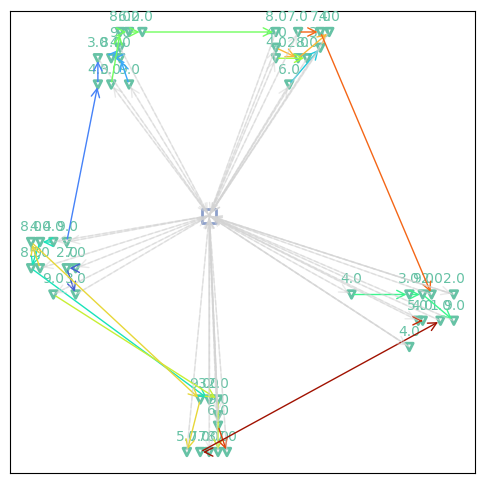

Cost:  22.488826751708984
Problem:  VRPTW


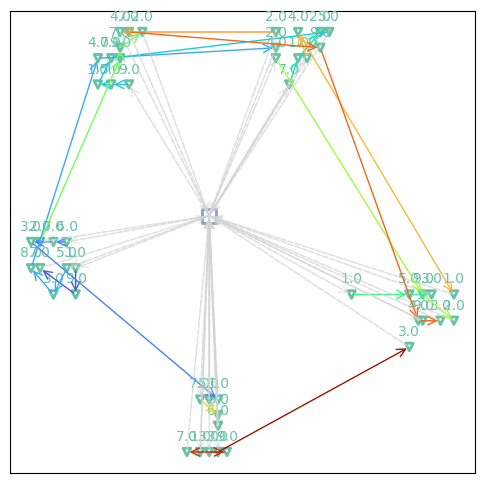

Cost:  24.643112182617188
Problem:  VRPTW


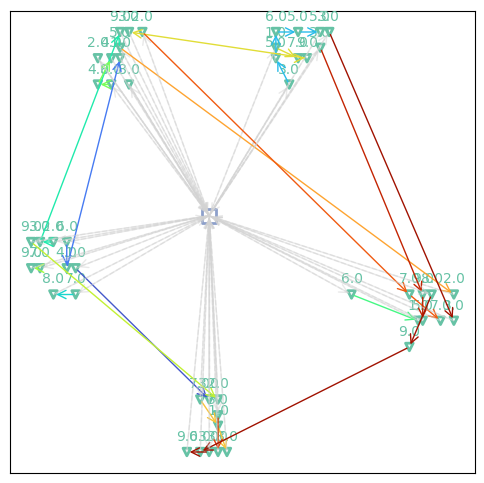

Cost:  26.365833282470703
Problem:  VRPTW
Averaged cost: 11.649
Problem 1 | Cost: 11.602
Variant VRPTW


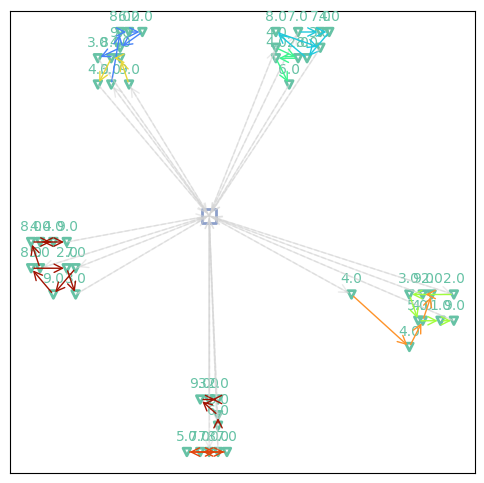

Problem 2 | Cost: 11.310
Variant VRPTW


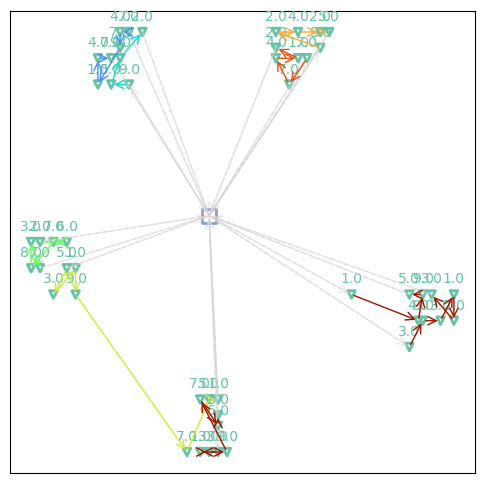

Problem 3 | Cost: 12.449
Variant VRPTW


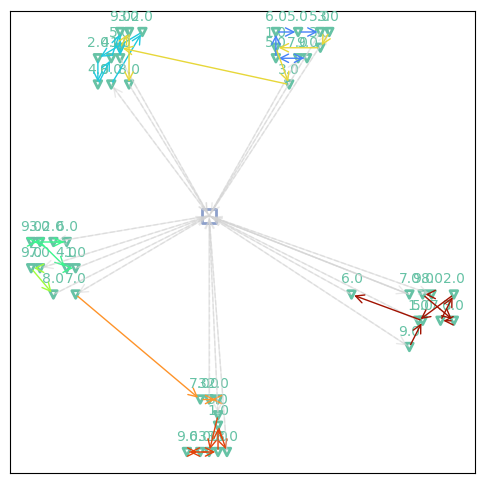

Averaged cost PyVRP: 12.164
Nearest Neighbor gap to HGS-PyVRP: 101.602%
RouteFinder gap to HGS-PyVRP: 0.127%


In [ ]:
from routefinder.utils import rollout, greedy_policy, evaluate
td_data = env.generator(50)
#td_test = env.reset(td_data)
# Generate data (mixed variants)
variant_names = env.get_variant_names(td_data)

td_test = env.reset(td_data)

actions = rollout(env, td_test.clone(), greedy_policy)
rewards_nearest_neighbor = env.get_reward(td_test, actions)

print(f"Averaged cost: {-rewards_nearest_neighbor.mean():.3f}")


for idx in [0,1,2]:
    env.render(td_test[idx], actions[idx])
    print("Cost: ", - rewards_nearest_neighbor[idx].item())
    print("Problem: ", variant_names[idx])
    

# Here we use `evaluate` to return the best augmented solution
td_test = td_test.to(device)
model = model.to(device)
out = evaluate(model, td_test.clone())

actions = out["best_aug_actions"]
rewards = env.get_reward(td_test, actions)

print(f"Averaged cost: {-rewards.mean():.3f}")

# Viz
for i in range(3):
    print(f"Problem {i+1} | Cost: {-rewards[i]:.3f}")
    print("Variant", env.get_variant_names(td_test[i]))
    env.render(td_test[i].cpu(), actions[i].cpu())
    
from routefinder.baselines.solve import solve

max_runtime = 3
num_procs = 32

td_test = td_test.cpu()

actions_pyvrp, costs_pyvrp = solve(td_test, max_runtime=max_runtime, num_procs=num_procs, solver="pyvrp")
rewards_pyvrp = env.get_reward(td_test.clone().cpu(), actions_pyvrp)

print(f"Averaged cost PyVRP: {-rewards_pyvrp.mean():.3f}")

from routefinder.baselines.solve import solve

def gap(sol, bks):
    return ((sol - bks) / bks).mean() * 100

print(f"Nearest Neighbor gap to HGS-PyVRP: {gap(rewards_nearest_neighbor.cpu(), rewards_pyvrp.cpu()):.3f}%")
print(f"RouteFinder gap to HGS-PyVRP: {gap(rewards.cpu(), rewards_pyvrp.cpu()):.3f}%")

In [ ]:
def summarize_td(td, name):
    tw = td["time_windows"][0].cpu()
    st = td["service_time"][0].cpu()

    starts = tw[:, 0]
    ends = tw[:, 1]
    widths = ends - starts

    print(f"\n{name}")
    print("depot due:", ends[0].item())
    print("start  min/mean/max:", starts.min().item(), starts.mean().item(), starts.max().item())
    print("end    min/mean/max:", ends.min().item(), ends.mean().item(), ends.max().item())
    print("width  min/mean/max:", widths.min().item(), widths.mean().item(), widths.max().item())
    print("service min/mean/max:", st.min().item(), st.mean().item(), st.max().item())

In [ ]:
summarize_td(env.generator(1), "train generator")
summarize_td(instance_to_routefinder_td(instances[0], normalize_coords=NORMALIZE_COORDS), "solomon inference")


train generator
depot due: 4.599999904632568
start  min/mean/max: 0.0 1.8464460372924805 3.9184136390686035
end    min/mean/max: 0.7009851932525635 2.1239073276519775 4.599999904632568
width  min/mean/max: 0.18033170700073242 0.27746137976646423 4.599999904632568
service min/mean/max: 0.0 0.1611848920583725 0.17965516448020935
Scaling times to target max time 4.6 with depot due time 11.321844100952148 and epsilon 1e-08

solomon inference
depot due: 4.599999904632568
start  min/mean/max: 0.0 1.656695008277893 3.756666660308838
end    min/mean/max: 0.7331249713897705 2.310616970062256 4.599999904632568
width  min/mean/max: 0.5749998092651367 0.6539215445518494 4.599999904632568
service min/mean/max: 0.0 0.04697712883353233 0.04791666567325592
